# 01 Data Preparation: Integrating MIMIC-IV & eICU Datasets

## Objectives
- Load MIMIC-IV (development data) and eICU (external validation data)
- Check and harmonize variable names across datasets
- Inspect data distributions for anomalies
- Combine the two datasets into a single analysis-ready file and save

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Data

In [5]:
# Load MIMIC-IV data
mimic_raw = pd.read_csv(r'../../data/mimic_iv_sepsis3_apache3_with_vitals.csv.gz', compression='gzip')
print(f'MIMIC-IV raw shape: {mimic_raw.shape}')
print(f'Columns: {mimic_raw.columns.tolist()}')
mimic_raw.head()

MIMIC-IV raw shape: (5513491, 18)
Columns: ['subject_id', 'hadm_id', 'stay_id', 'icu_intime', 'age', 'sex', 'race', 'vent', 'uop', 'admit', 'arf', 'comorbidity', 'apache3_score', 'hospital_expire_flag', 'charttime', 'variable_name', 'value', 'data_source']


,subject_id,hadm_id,stay_id,icu_intime,age,sex,race,vent,uop,admit,arf,comorbidity,apache3_score,hospital_expire_flag,charttime,variable_name,value,data_source
0,17892019,23189806,30803084,2138-02-14 17:02:00,35,M,UNABLE TO OBTAIN,False,2180.0,emergency,False,NaN,3,0,2138-02-15 04:00:00,fio2,95.0,fio2_chartevents
1,17892019,23189806,30803084,2138-02-14 17:02:00,35,M,UNABLE TO OBTAIN,False,2180.0,emergency,False,NaN,3,0,2138-02-15 03:00:00,map,83.0,vitalsign
2,17892019,23189806,30803084,2138-02-14 17:02:00,35,M,UNABLE TO OBTAIN,False,2180.0,emergency,False,NaN,3,0,2138-02-15 09:00:00,map,91.0,vitalsign
3,17892019,23189806,30803084,2138-02-14 17:02:00,35,M,UNABLE TO OBTAIN,False,2180.0,emergency,False,NaN,3,0,2138-02-15 10:00:00,gcs_eye,4.0,gcs
4,17892019,23189806,30803084,2138-02-14 17:02:00,35,M,UNABLE TO OBTAIN,False,2180.0,emergency,False,NaN,3,0,2138-02-15 08:00:00,fio2,30.0,fio2_chartevents


In [6]:
# Load eICU data (note: file extension is .cvs.gz)
eicu_raw = pd.read_csv(r'../../data/eicu_sepsis3_apache3_with_vitals.csv.gz', compression='gzip')
print(f'eICU raw shape: {eicu_raw.shape}')
print(f'Columns: {eicu_raw.columns.tolist()}')
eicu_raw.head()

eICU raw shape: (5473554, 19)
Columns: ['uniquepid', 'patientunitstayid', 'hospitalid', 'age', 'sex', 'ethnicity', 'teachingstatus', 'region', 'vent', 'uop', 'admit', 'arf', 'comorbidity', 'apache3_score', 'hospital_expire_flag', 'observationoffset', 'variable_name', 'value', 'data_source']


,uniquepid,patientunitstayid,hospitalid,age,sex,ethnicity,teachingstatus,region,vent,uop,admit,arf,comorbidity,apache3_score,hospital_expire_flag,observationoffset,variable_name,value,data_source
0,002-10949,225206,56,90,F,Caucasian,False,Midwest,False,800.0,emergency,False,NaN,61,0,170.0,hr,92.0,vitalsign
1,002-10949,225206,56,90,F,Caucasian,False,Midwest,False,800.0,emergency,False,NaN,61,0,1145.0,map,61.0,vitalsign
2,002-10949,225206,56,90,F,Caucasian,False,Midwest,False,800.0,emergency,False,NaN,61,0,125.0,rr,29.0,vitalsign
3,002-12306,190338,56,66,M,Caucasian,False,Midwest,False,0.0,emergency,False,NaN,41,0,188.0,hr,100.0,vitalsign
4,002-12306,190338,56,66,M,Caucasian,False,Midwest,False,0.0,emergency,False,NaN,41,0,533.0,rr,26.0,vitalsign


## 2. Compare Variable Names

In [7]:
# Compare column names between datasets
mimic_cols = set(mimic_raw.columns)
eicu_cols = set(eicu_raw.columns)

print('=== Column Name Comparison ===')
print(f'\nMIMIC-IV only ({len(mimic_cols - eicu_cols)}): {sorted(mimic_cols - eicu_cols)}')
print(f'\neICU only ({len(eicu_cols - mimic_cols)}): {sorted(eicu_cols - mimic_cols)}')
print(f'\nShared ({len(mimic_cols & eicu_cols)}): {sorted(mimic_cols & eicu_cols)}')

=== Column Name Comparison ===

MIMIC-IV only (6): ['charttime', 'hadm_id', 'icu_intime', 'race', 'stay_id', 'subject_id']

eICU only (7): ['ethnicity', 'hospitalid', 'observationoffset', 'patientunitstayid', 'region', 'teachingstatus', 'uniquepid']

Shared (12): ['admit', 'age', 'apache3_score', 'arf', 'comorbidity', 'data_source', 'hospital_expire_flag', 'sex', 'uop', 'value', 'variable_name', 'vent']


In [8]:
# Compare data types for shared columns
common_cols = sorted(mimic_cols & eicu_cols)
print('=== Data Type Comparison ===')
dtype_comparison = pd.DataFrame({
    'MIMIC-IV': mimic_raw[common_cols].dtypes,
    'eICU': eicu_raw[common_cols].dtypes
})
dtype_comparison['match'] = dtype_comparison['MIMIC-IV'] == dtype_comparison['eICU']
print(dtype_comparison)
print(f'\nMismatched columns: {dtype_comparison[~dtype_comparison["match"]].index.tolist()}')

=== Data Type Comparison ===
                     MIMIC-IV     eICU  match
admit                  object   object   True
age                     int64    int64   True
apache3_score           int64    int64   True
arf                      bool     bool   True
comorbidity            object   object   True
data_source            object   object   True
hospital_expire_flag    int64    int64   True
sex                    object   object   True
uop                   float64  float64   True
value                 float64  float64   True
variable_name          object   object   True
vent                     bool     bool   True

Mismatched columns: []


In [9]:
# Compare variable_name values (for long format data)
if 'variable_name' in mimic_raw.columns and 'variable_name' in eicu_raw.columns:
    mimic_vars = set(mimic_raw['variable_name'].dropna().unique())
    eicu_vars = set(eicu_raw['variable_name'].dropna().unique())
    
    # Check for NaN in variable_name
    mimic_nan = mimic_raw['variable_name'].isna().sum()
    eicu_nan = eicu_raw['variable_name'].isna().sum()
    
    print('=== variable_name Comparison ===')
    print(f'\nMIMIC-IV variable_name ({len(mimic_vars)}): {sorted(mimic_vars)}')
    if mimic_nan > 0:
        print(f'  (NaN rows: {mimic_nan})')
    print(f'\neICU variable_name ({len(eicu_vars)}): {sorted(eicu_vars)}')
    if eicu_nan > 0:
        print(f'  (NaN rows: {eicu_nan})')
    print(f'\nMIMIC-IV only: {sorted(mimic_vars - eicu_vars)}')
    print(f'eICU only: {sorted(eicu_vars - mimic_vars)}')
    print(f'Shared: {sorted(mimic_vars & eicu_vars)}')
else:
    print('variable_name column not found (data may be in wide format)')

=== variable_name Comparison ===

MIMIC-IV variable_name (20): ['aa_grad', 'albumin', 'bili', 'bun', 'fio2', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'glucose', 'hct', 'hr', 'map', 'pao2', 'pco2', 'ph', 'rr', 'scr', 'sodium', 'temp', 'wbc']

eICU variable_name (20): ['aa_grad', 'albumin', 'bili', 'bun', 'fio2', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'glucose', 'hct', 'hr', 'map', 'pao2', 'pco2', 'ph', 'rr', 'scr', 'sodium', 'temp', 'wbc']
  (NaN rows: 7)

MIMIC-IV only: []
eICU only: []
Shared: ['aa_grad', 'albumin', 'bili', 'bun', 'fio2', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'glucose', 'hct', 'hr', 'map', 'pao2', 'pco2', 'ph', 'rr', 'scr', 'sodium', 'temp', 'wbc']


## 3. Fix Variable Name Discrepancies

Based on the comparison in Section 2:
- **Column names**: All 20 `variable_name` values are identical between MIMIC-IV and eICU. No renaming needed.
- **Data types**: All shared columns have matching types. No conversion needed.
- **NaN in `variable_name`**: eICU contains 7 rows where `variable_name` is NaN. These correspond to 7 patients who have no vital sign or laboratory data at all (only 1 row each, with all clinical observation fields as NaN). Their APACHE III scores exist because eICU stores APACHE scores in a separate table (`apachePatientResult`), which was available even though no charted vitals/labs were found in the observation tables. Since these patients have no usable clinical variables, they are excluded below.

In [10]:
# Exclude eICU patients with no clinical observations (7 patients)
n_before = len(eicu_raw)
nan_ids = eicu_raw.loc[eicu_raw['variable_name'].isna(), 'patientunitstayid'].tolist()
eicu_raw = eicu_raw[~eicu_raw['patientunitstayid'].isin(nan_ids)]
n_after = len(eicu_raw)

print(f'Excluded {len(nan_ids)} eICU patients with no vital/lab data')
print(f'  Patient IDs: {nan_ids}')
print(f'  eICU rows: {n_before} -> {n_after}')

Excluded 7 eICU patients with no vital/lab data
  Patient IDs: [971030, 168071, 623669, 977284, 960238, 963674, 969926]
  eICU rows: 5473554 -> 5473547


In [11]:
# Inspect the 7 eICU rows with NaN variable_name
eicu_raw[eicu_raw['variable_name'].isna()]

,uniquepid,patientunitstayid,hospitalid,age,sex,ethnicity,teachingstatus,region,vent,uop,admit,arf,comorbidity,apache3_score,hospital_expire_flag,observationoffset,variable_name,value,data_source


In [12]:
# Check all rows for these 7 patients
nan_ids = eicu_raw.loc[eicu_raw['variable_name'].isna(), 'patientunitstayid'].tolist()
print(f'Patient IDs with NaN variable_name: {nan_ids}')
print(f'Total rows for these patients: {eicu_raw["patientunitstayid"].isin(nan_ids).sum()}')
print()
eicu_raw[eicu_raw['patientunitstayid'].isin(nan_ids)]

Patient IDs with NaN variable_name: []
Total rows for these patients: 0



,uniquepid,patientunitstayid,hospitalid,age,sex,ethnicity,teachingstatus,region,vent,uop,admit,arf,comorbidity,apache3_score,hospital_expire_flag,observationoffset,variable_name,value,data_source


## 4. Convert Long to Wide Format

If the data is in long format, convert it to wide format for analysis.

In [13]:
def long_to_wide(df, dataset_name='dataset'):
    """Convert long format data to wide format.
    
    Uses the value closest to ICU admission time for each variable.
    For eICU data (observationoffset), uses the value closest to offset=0.
    """
    # Identify the patient ID column
    if 'stay_id' in df.columns:
        id_col = 'stay_id'
    elif 'patientunitstayid' in df.columns:
        df = df.rename(columns={'patientunitstayid': 'stay_id'})
        id_col = 'stay_id'
    else:
        raise ValueError(f'ID column not found in {dataset_name}')
    
    # Identify patient-level columns (not time-varying)
    exclude_cols = ['charttime', 'variable_name', 'value', 'data_source', 
                    'icu_intime', 'observationoffset', 'time_diff']
    patient_level_cols = [c for c in df.columns if c not in exclude_cols]
    
    # Extract one row per patient
    patient_data = df.groupby(id_col).first()[
        [c for c in patient_level_cols if c != id_col]
    ].reset_index()
    
    print(f'{dataset_name} - Patient data shape: {patient_data.shape}')
    
    # Pivot long to wide (use value closest to ICU admission)
    if 'variable_name' in df.columns and 'value' in df.columns:
        if 'icu_intime' in df.columns and 'charttime' in df.columns:
            # MIMIC-IV: use absolute time difference
            df['icu_intime'] = pd.to_datetime(df['icu_intime'])
            df['charttime'] = pd.to_datetime(df['charttime'])
            df['time_diff'] = abs(df['charttime'] - df['icu_intime'])
        elif 'observationoffset' in df.columns:
            # eICU: offset=0 is ICU admission, use absolute offset
            df['time_diff'] = df['observationoffset'].abs()
        else:
            df['time_diff'] = 0
        
        # Select the row closest to admission for each patient-variable pair
        idx = df.groupby([id_col, 'variable_name'])['time_diff'].idxmin()
        wide_data = df.loc[idx]
        
        wide_data = wide_data.pivot_table(
            index=id_col,
            columns='variable_name',
            values='value',
            aggfunc='first'
        ).reset_index()
        
        # Merge patient data with pivoted clinical variables
        patient_cols_to_use = [id_col] + [c for c in patient_data.columns 
                                          if c != id_col and c not in wide_data.columns]
        df_wide = pd.merge(patient_data[patient_cols_to_use], wide_data, on=id_col, how='left')
    else:
        df_wide = patient_data
    
    print(f'{dataset_name} - Wide data shape: {df_wide.shape}')
    print(f'{dataset_name} - Columns: {df_wide.columns.tolist()}')
    return df_wide

In [14]:
# Convert MIMIC-IV to wide format
mimic_wide = long_to_wide(mimic_raw.copy(), 'MIMIC-IV')

MIMIC-IV - Patient data shape: (30218, 13)
MIMIC-IV - Wide data shape: (30218, 33)
MIMIC-IV - Columns: ['stay_id', 'subject_id', 'hadm_id', 'age', 'sex', 'race', 'vent', 'uop', 'admit', 'arf', 'comorbidity', 'apache3_score', 'hospital_expire_flag', 'aa_grad', 'albumin', 'bili', 'bun', 'fio2', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'glucose', 'hct', 'hr', 'map', 'pao2', 'pco2', 'ph', 'rr', 'scr', 'sodium', 'temp', 'wbc']


In [15]:
# Convert eICU to wide format
eicu_wide = long_to_wide(eicu_raw.copy(), 'eICU')

eICU - Patient data shape: (31403, 15)
eICU - Wide data shape: (31403, 35)
eICU - Columns: ['stay_id', 'uniquepid', 'hospitalid', 'age', 'sex', 'ethnicity', 'teachingstatus', 'region', 'vent', 'uop', 'admit', 'arf', 'comorbidity', 'apache3_score', 'hospital_expire_flag', 'aa_grad', 'albumin', 'bili', 'bun', 'fio2', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'glucose', 'hct', 'hr', 'map', 'pao2', 'pco2', 'ph', 'rr', 'scr', 'sodium', 'temp', 'wbc']


In [16]:
# Compare columns after wide format conversion
mimic_wide_cols = set(mimic_wide.columns)
eicu_wide_cols = set(eicu_wide.columns)

print('=== Wide Format Column Comparison ===')
print(f'\nMIMIC-IV only ({len(mimic_wide_cols - eicu_wide_cols)}): {sorted(mimic_wide_cols - eicu_wide_cols)}')
print(f'\neICU only ({len(eicu_wide_cols - mimic_wide_cols)}): {sorted(eicu_wide_cols - mimic_wide_cols)}')
print(f'\nShared ({len(mimic_wide_cols & eicu_wide_cols)}): {sorted(mimic_wide_cols & eicu_wide_cols)}')

=== Wide Format Column Comparison ===

MIMIC-IV only (3): ['hadm_id', 'race', 'subject_id']

eICU only (5): ['ethnicity', 'hospitalid', 'region', 'teachingstatus', 'uniquepid']

Shared (30): ['aa_grad', 'admit', 'age', 'albumin', 'apache3_score', 'arf', 'bili', 'bun', 'comorbidity', 'fio2', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'glucose', 'hct', 'hospital_expire_flag', 'hr', 'map', 'pao2', 'pco2', 'ph', 'rr', 'scr', 'sex', 'sodium', 'stay_id', 'temp', 'uop', 'vent', 'wbc']


## 5. Inspect Data Distributions

In [17]:
# Summary statistics for MIMIC-IV
print('=== MIMIC-IV Summary Statistics ===')
display(mimic_wide.describe())
print(f'\nNumber of patients: {len(mimic_wide)}')

=== MIMIC-IV Summary Statistics ===


,stay_id,subject_id,hadm_id,age,uop,apache3_score,hospital_expire_flag,aa_grad,albumin,bili,bun,fio2,gcs_eye,gcs_motor,gcs_verbal,glucose,hct,hr,map,pao2,pco2,ph,rr,scr,sodium,temp,wbc
count,3.021800e+04,3.021800e+04,3.021800e+04,30218.000000,30218.000000,30218.000000,30218.000000,18815.000000,13112.000000,17919.000000,30097.00000,30197.000000,30178.000000,30174.000000,23292.000000,29989.000000,30062.000000,30188.000000,30187.000000,24261.000000,24260.000000,24260.000000,30171.000000,30104.000000,30106.000000,28776.000000,30044.000000
mean,3.497041e+07,1.502320e+07,2.500766e+07,66.029022,1732.663868,74.080680,0.163015,300.657601,3.130987,2.032379,28.01761,92.548299,2.638511,4.205110,4.184312,148.176531,31.781448,90.271499,82.250257,173.857343,42.631369,7.361026,19.589258,1.497615,138.307713,36.690321,13.255301
std,2.883631e+06,2.887091e+06,2.886079e+06,15.979739,1266.701336,27.703922,0.369386,166.873556,0.715671,4.558793,23.06544,14.823949,1.359100,2.193016,1.418333,74.955968,6.737133,20.445297,18.476326,134.241004,12.457346,0.100851,6.294411,1.542281,5.447280,0.926935,10.417589
min,3.000065e+07,1.000069e+07,2.000015e+07,18.000000,-14850.000000,3.000000,0.000000,0.000000,0.300000,0.100000,1.00000,21.000000,1.000000,1.000000,1.000000,7.000000,10.500000,2.000000,1.000000,12.000000,9.000000,6.530000,1.000000,0.100000,100.000000,26.300000,0.100000
25%,3.248756e+07,1.254118e+07,2.251492e+07,56.000000,890.000000,54.000000,0.000000,162.050000,2.600000,0.400000,14.00000,94.000000,1.000000,1.000000,4.000000,106.000000,26.900000,77.000000,70.000000,64.000000,35.000000,7.310000,15.000000,0.700000,136.000000,36.390000,8.100000
50%,3.494838e+07,1.503640e+07,2.502066e+07,67.000000,1510.000000,70.000000,0.000000,273.500000,3.100000,0.700000,20.00000,98.000000,3.000000,6.000000,5.000000,129.000000,31.400000,88.000000,80.000000,120.000000,41.000000,7.380000,18.000000,1.000000,139.000000,36.720000,11.600000
75%,3.745536e+07,1.754335e+07,2.750066e+07,78.000000,2325.000000,90.000000,0.000000,437.000000,3.600000,1.500000,34.00000,100.000000,4.000000,6.000000,5.000000,166.000000,36.100000,103.000000,92.000000,278.000000,47.000000,7.430000,23.000000,1.600000,141.000000,37.110000,16.200000
max,3.999955e+07,1.999984e+07,2.999962e+07,103.000000,30595.000000,217.000000,1.000000,653.750000,5.800000,49.000000,240.00000,100.000000,4.000000,6.000000,5.000000,993.000000,66.400000,191.000000,246.000000,681.000000,181.000000,7.780000,66.000000,24.600000,185.000000,42.000000,366.300000



Number of patients: 30218


In [18]:
# Summary statistics for eICU
print('=== eICU Summary Statistics ===')
display(eicu_wide.describe())
print(f'\nNumber of patients: {len(eicu_wide)}')

=== eICU Summary Statistics ===


,stay_id,hospitalid,age,uop,apache3_score,hospital_expire_flag,aa_grad,albumin,bili,bun,fio2,gcs_eye,gcs_motor,gcs_verbal,glucose,hct,hr,map,pao2,pco2,ph,rr,scr,sodium,temp,wbc
count,3.140300e+04,31403.000000,31403.000000,31403.000000,31403.000000,31403.000000,12977.000000,22531.000000,21870.000000,30709.000000,20922.000000,22147.000000,22142.000000,21985.000000,30684.000000,30956.000000,30768.000000,30826.000000,20846.000000,13252.000000,20150.000000,30013.000000,30715.000000,30771.000000,30972.000000,30870.000000
mean,1.568138e+06,248.049932,65.223291,1230.656402,69.391332,0.139127,263.728736,2.950956,1.255728,30.170523,59.381484,3.194699,5.187517,3.301114,157.014959,33.784882,91.868305,81.750762,148.709810,41.410176,7.340647,20.549728,1.755263,138.108489,36.724546,13.772528
std,9.124889e+05,107.115953,15.879254,1480.638913,28.747162,0.346084,165.990879,0.727914,2.579521,23.767814,26.124299,1.107401,1.504392,1.808200,86.317428,7.318461,21.580588,20.439717,101.092657,12.520992,0.106607,7.140722,1.911200,5.772950,0.954296,9.382394
min,1.412030e+05,56.000000,18.000000,0.000000,4.000000,0.000000,0.000000,0.300000,0.000000,1.000000,21.000000,1.000000,1.000000,1.000000,2.000000,10.100000,26.000000,1.000000,15.000000,7.000000,6.630000,1.000000,0.100000,100.000000,25.600000,0.000000
25%,8.866785e+05,176.000000,56.000000,0.000000,49.000000,0.000000,132.400000,2.400000,0.400000,15.000000,40.000000,3.000000,5.000000,1.000000,108.000000,28.600000,77.000000,68.000000,79.000000,34.000000,7.288000,16.000000,0.810000,135.000000,36.300000,8.500000
50%,1.563166e+06,248.000000,67.000000,923.000000,65.000000,0.000000,220.000000,3.000000,0.600000,23.000000,50.000000,4.000000,6.000000,4.000000,135.000000,33.600000,90.000000,79.000000,111.400000,39.800000,7.350000,19.000000,1.170000,138.000000,36.700000,12.200000
75%,2.289468e+06,328.000000,77.000000,1850.000000,85.000000,0.000000,386.250000,3.500000,1.100000,38.000000,80.000000,4.000000,6.000000,5.000000,177.000000,38.700000,106.000000,93.000000,185.000000,46.100000,7.410000,24.000000,1.880000,141.000000,37.160000,17.100000
max,3.353144e+06,459.000000,90.000000,89175.000000,208.000000,1.000000,650.375000,6.000000,48.000000,298.000000,100.000000,4.000000,6.000000,5.000000,998.000000,72.400000,209.000000,249.000000,668.000000,128.000000,7.895000,60.000000,30.000000,195.000000,41.700000,498.800000



Number of patients: 31403


In [19]:
# Compare distributions of categorical variables
categorical_candidates = ['sex', 'vent', 'arf', 'comorbidity', 'admit', 'hospital_expire_flag']

for col in categorical_candidates:
    print(f'\n=== {col} ===')
    if col in mimic_wide.columns:
        print('MIMIC-IV:')
        print(mimic_wide[col].value_counts(dropna=False))
    else:
        print('MIMIC-IV: column not found')
    
    if col in eicu_wide.columns:
        print('eICU:')
        print(eicu_wide[col].value_counts(dropna=False))
    else:
        print('eICU: column not found')


=== sex ===
MIMIC-IV:
sex
M    17562
F    12656
Name: count, dtype: int64
eICU:
sex
M       17404
F       13996
None        3
Name: count, dtype: int64

=== vent ===
MIMIC-IV:
vent
False    15555
True     14663
Name: count, dtype: int64
eICU:
vent
False    21592
True      9811
Name: count, dtype: int64

=== arf ===
MIMIC-IV:
arf
False    27675
True      2543
Name: count, dtype: int64
eICU:
arf
False    26162
True      5241
Name: count, dtype: int64

=== comorbidity ===
MIMIC-IV:
comorbidity
None               23401
hepatic_failure     2171
cancer_mets         1836
cirrhosis           1422
lymphoma             542
leukemia             448
aids                 203
immunosuppress       128
mult_myeloma          67
Name: count, dtype: int64
eICU:
comorbidity
None               27994
cancer_mets          832
hepatic_failure      806
immunosuppress       699
cirrhosis            457
leukemia             359
lymphoma             213
aids                  43
Name: count, dtype: int64

=== adm

In [20]:
# Compare missing values
print('=== Missing Value Comparison ===')
common_wide_cols = sorted(set(mimic_wide.columns) & set(eicu_wide.columns))

missing_comparison = pd.DataFrame({
    'MIMIC-IV_n': mimic_wide[common_wide_cols].isnull().sum(),
    'MIMIC-IV_%': (mimic_wide[common_wide_cols].isnull().sum() / len(mimic_wide) * 100).round(1),
    'eICU_n': eicu_wide[common_wide_cols].isnull().sum(),
    'eICU_%': (eicu_wide[common_wide_cols].isnull().sum() / len(eicu_wide) * 100).round(1),
})
display(missing_comparison)

=== Missing Value Comparison ===


,MIMIC-IV_n,MIMIC-IV_%,eICU_n,eICU_%
aa_grad,11403,37.7,18426,58.7
admit,0,0.0,0,0.0
age,0,0.0,0,0.0
albumin,17106,56.6,8872,28.3
apache3_score,0,0.0,0,0.0
arf,0,0.0,0,0.0
bili,12299,40.7,9533,30.4
bun,121,0.4,694,2.2
comorbidity,23401,77.4,27994,89.1
fio2,21,0.1,10481,33.4


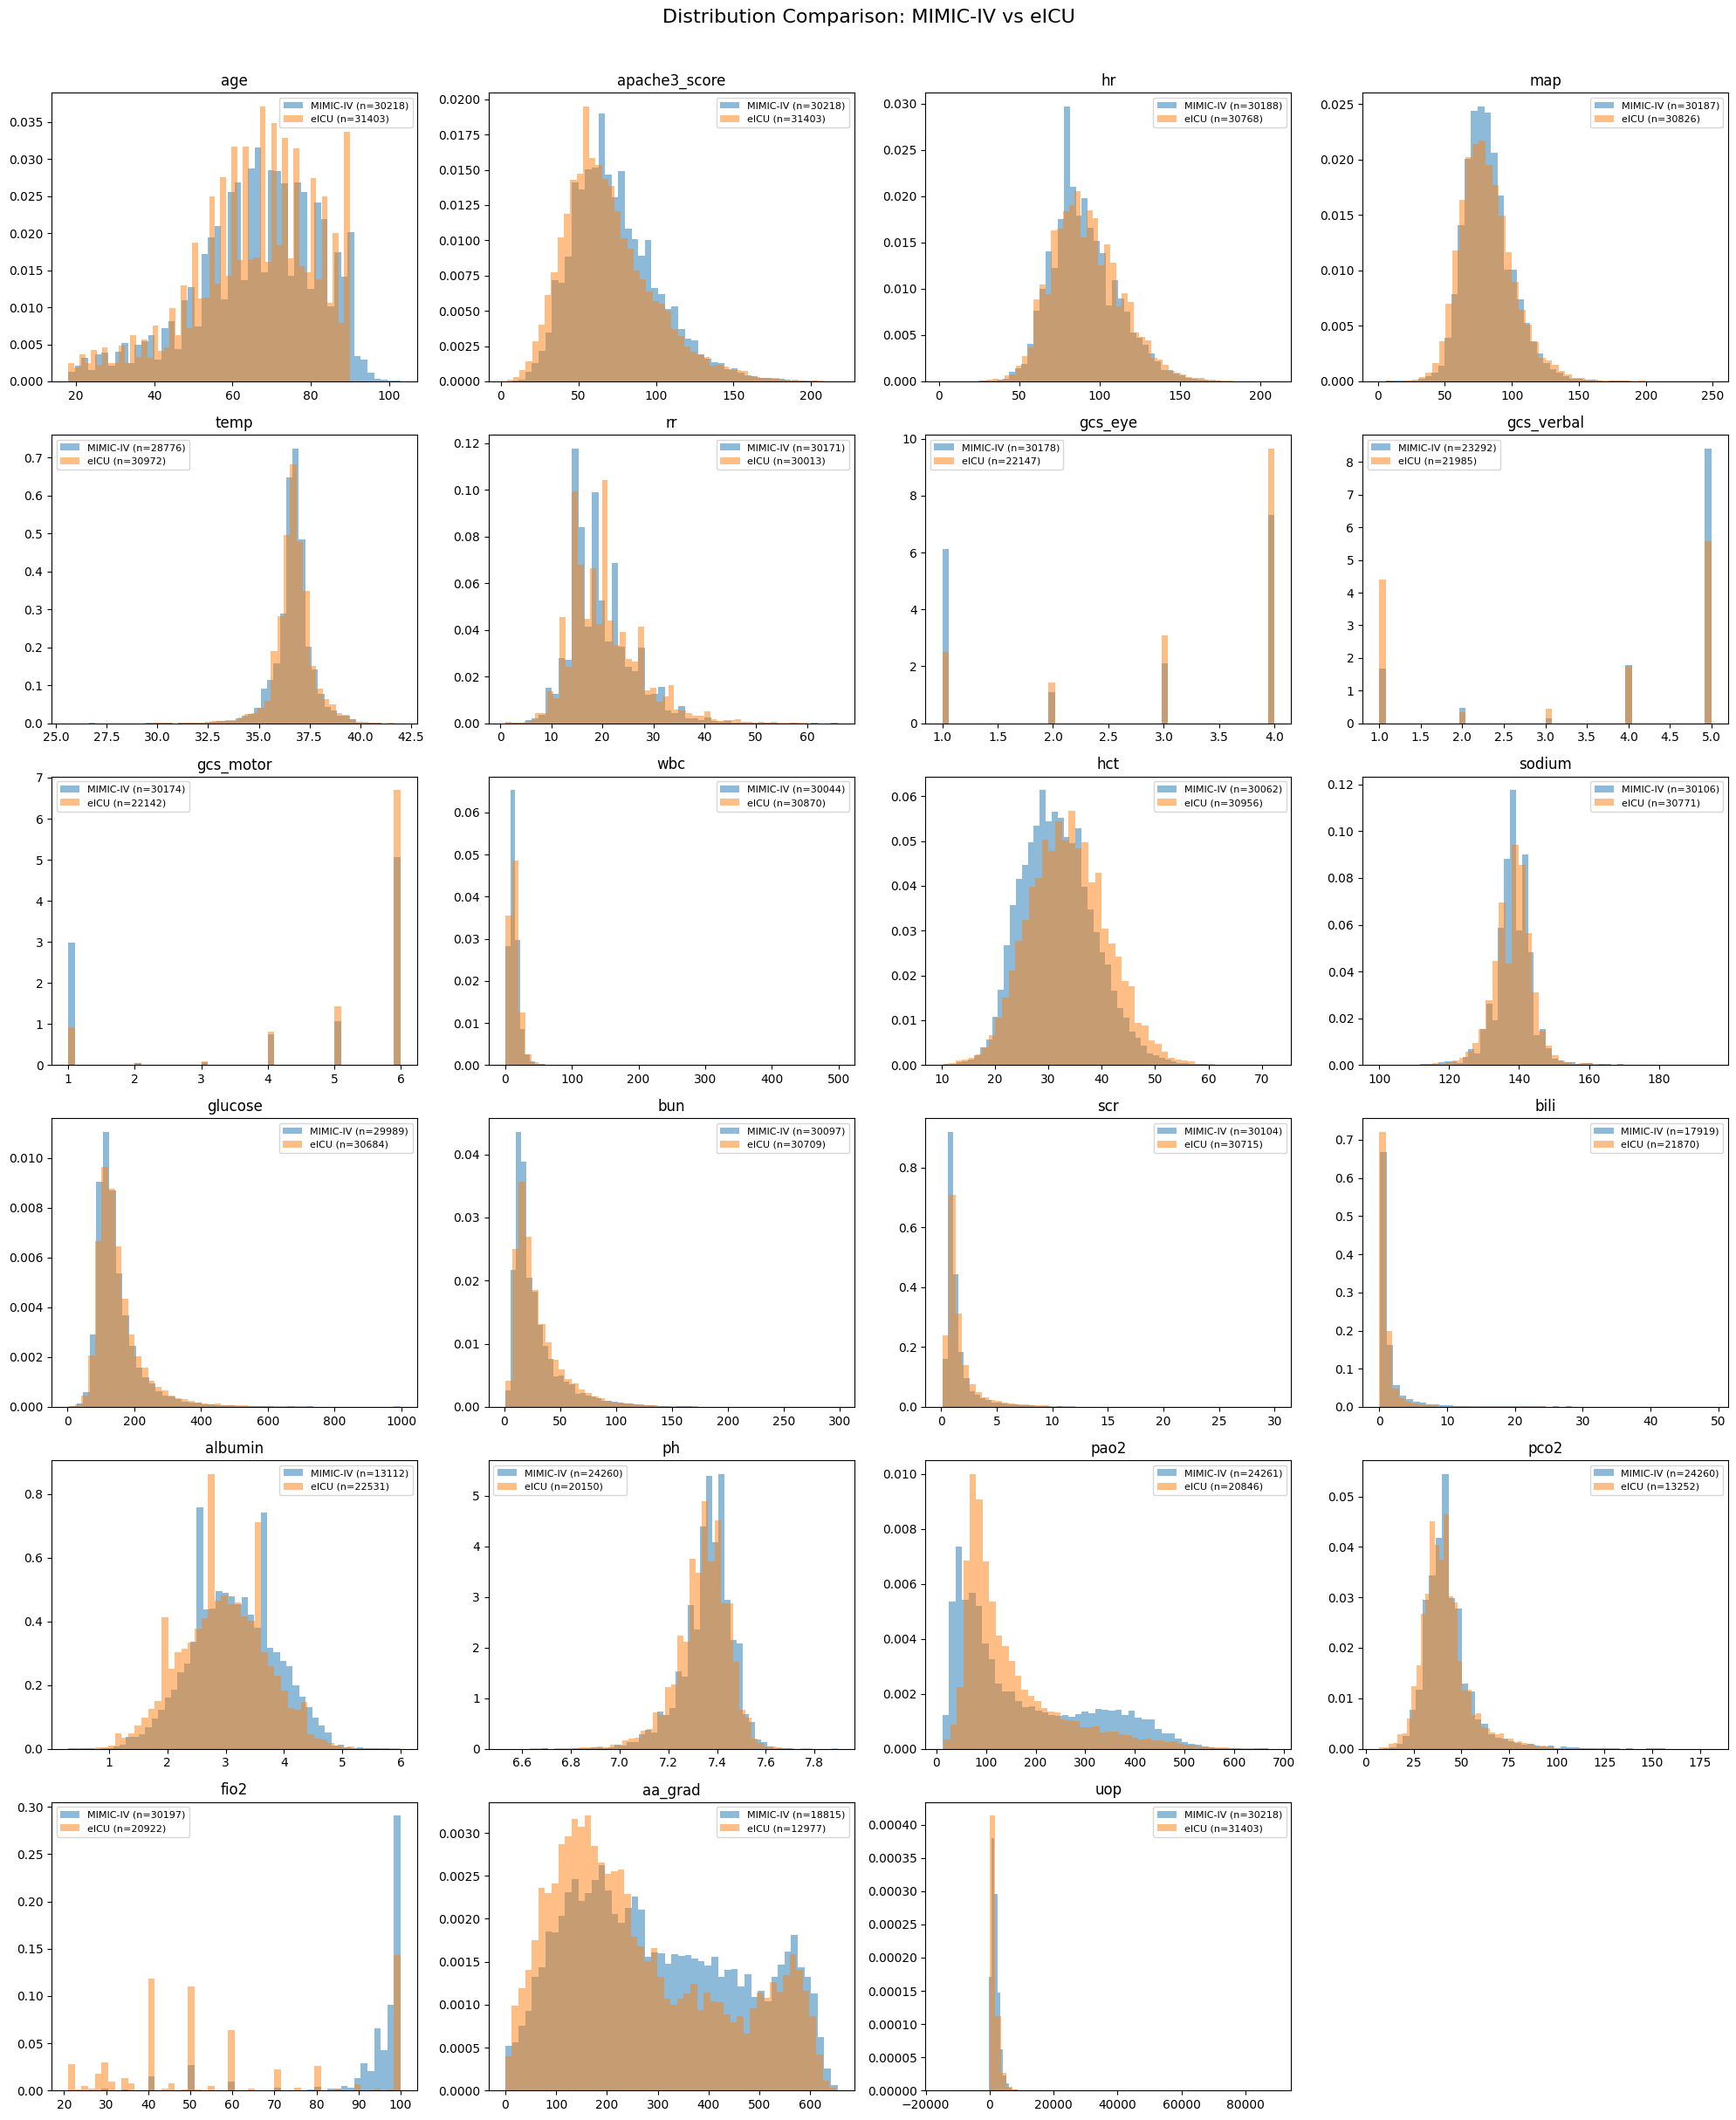

Saved to: ../../output/outputs_for_manuscript


In [21]:
# Visual comparison of continuous variable distributions
numerical_vars = ['age', 'apache3_score', 'hr', 'map', 'temp', 'rr',
                  'gcs_eye', 'gcs_verbal', 'gcs_motor',
                  'wbc', 'hct', 'sodium', 'glucose', 'bun', 'scr', 'bili', 'albumin',
                  'ph', 'pao2', 'pco2', 'fio2', 'aa_grad', 'uop']

# Only plot variables present in both datasets
plot_vars = [v for v in numerical_vars if v in mimic_wide.columns and v in eicu_wide.columns]

n_vars = len(plot_vars)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    mimic_vals = mimic_wide[var].dropna()
    eicu_vals = eicu_wide[var].dropna()
    
    ax.hist(mimic_vals, bins=50, alpha=0.5, label=f'MIMIC-IV (n={len(mimic_vals)})', density=True)
    ax.hist(eicu_vals, bins=50, alpha=0.5, label=f'eICU (n={len(eicu_vals)})', density=True)
    ax.set_title(var)
    ax.legend(fontsize=8)

# Hide unused subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution Comparison: MIMIC-IV vs eICU', fontsize=16, y=1.01)
plt.tight_layout()

# 保存
save_path = r"../../output/outputs_for_manuscript"
fig.savefig(f"{save_path}/S.Figure 1distribution_comparison_mimic_eicu.png", dpi=300, bbox_inches='tight')

plt.show()
print(f"Saved to: {save_path}")

## 6. Combine Datasets (Long Format)

Combine MIMIC-IV (development/training) and eICU (external validation) in **long format** to preserve measurement frequency and temporal information.  
The wide format conversion above (Section 4-5) was used only for distribution inspection.

### Time column harmonization
MIMIC-IV and eICU represent measurement timing differently:
- **MIMIC-IV**: `icu_intime` (absolute ICU admission datetime) + `charttime` (absolute measurement datetime)
- **eICU**: `observationoffset` (minutes relative to ICU admission; offset=0 means admission)

To create a unified time variable, MIMIC-IV's `observationoffset` is computed as `(charttime - icu_intime)` in minutes. After conversion, `observationoffset` is available for all rows across both datasets and can be used directly for temporal analysis. The original `icu_intime` and `charttime` columns are retained for MIMIC-IV rows only (NaN for eICU).

### Race/Ethnicity harmonization
MIMIC-IV has 33 granular `race` categories; eICU has 6 broad `ethnicity` categories.  
We map both to a unified `race_ethnicity` column with 5 categories: **White, Black, Asian, Hispanic, Other/Unknown**.

In [22]:
# --- Harmonize race/ethnicity across MIMIC-IV and eICU ---
race_map_mimic = {
    # White
    'WHITE': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'PORTUGUESE': 'White',
    # Black
    'BLACK/AFRICAN AMERICAN': 'Black',
    'BLACK/CAPE VERDEAN': 'Black',
    'BLACK/CARIBBEAN ISLAND': 'Black',
    'BLACK/AFRICAN': 'Black',
    # Asian
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - SOUTH EAST ASIAN': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    # Hispanic
    'HISPANIC OR LATINO': 'Hispanic',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic',
    'HISPANIC/LATINO - HONDURAN': 'Hispanic',
    'HISPANIC/LATINO - CUBAN': 'Hispanic',
    'HISPANIC/LATINO - COLUMBIAN': 'Hispanic',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'Hispanic',
    'SOUTH AMERICAN': 'Hispanic',
    # Other/Unknown
    'OTHER': 'Other/Unknown',
    'UNKNOWN': 'Other/Unknown',
    'UNABLE TO OBTAIN': 'Other/Unknown',
    'PATIENT DECLINED TO ANSWER': 'Other/Unknown',
    'MULTIPLE RACE/ETHNICITY': 'Other/Unknown',
    'AMERICAN INDIAN/ALASKA NATIVE': 'Other/Unknown',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Other/Unknown',
}

race_map_eicu = {
    'Caucasian': 'White',
    'African American': 'Black',
    'Asian': 'Asian',
    'Hispanic': 'Hispanic',
    'Native American': 'Other/Unknown',
    'Other/Unknown': 'Other/Unknown',
}

# Apply mapping
mimic_raw['race_ethnicity'] = mimic_raw['race'].map(race_map_mimic)
eicu_raw['race_ethnicity'] = eicu_raw['ethnicity'].map(race_map_eicu)

# Check for unmapped values (NaN after mapping)
mimic_unmapped = mimic_raw.loc[mimic_raw['race_ethnicity'].isna(), 'race'].unique()
eicu_unmapped = eicu_raw.loc[eicu_raw['race_ethnicity'].isna(), 'ethnicity'].unique()
print(f'MIMIC-IV unmapped race values: {mimic_unmapped}')
print(f'eICU unmapped ethnicity values: {eicu_unmapped}')

# Distribution comparison
print('\n=== race_ethnicity Distribution ===')
print('\nMIMIC-IV (patient-level):')
mimic_re = mimic_raw.groupby('stay_id')['race_ethnicity'].first().value_counts(dropna=False)
print(mimic_re)
print(f'\neICU (patient-level):')
eicu_re = eicu_raw.groupby('patientunitstayid')['race_ethnicity'].first().value_counts(dropna=False)
print(eicu_re)

MIMIC-IV unmapped race values: []
eICU unmapped ethnicity values: [nan]

=== race_ethnicity Distribution ===

MIMIC-IV (patient-level):
race_ethnicity
White            20093
Other/Unknown     5538
Black             2654
Hispanic          1071
Asian              862
Name: count, dtype: int64

eICU (patient-level):
race_ethnicity
White            25483
Black             2988
Other/Unknown     1748
Hispanic           612
Asian              426
None               146
Name: count, dtype: int64


In [23]:
# Harmonize columns for long format combination
mimic_long = mimic_raw.copy()
eicu_long = eicu_raw.copy()

# --- Compute observationoffset for MIMIC-IV (minutes from ICU admission) ---
mimic_long['icu_intime'] = pd.to_datetime(mimic_long['icu_intime'])
mimic_long['charttime'] = pd.to_datetime(mimic_long['charttime'])
mimic_long['observationoffset'] = (
    (mimic_long['charttime'] - mimic_long['icu_intime']).dt.total_seconds() / 60.0
)
print('MIMIC-IV observationoffset computed (charttime - icu_intime in minutes):')
print(mimic_long['observationoffset'].describe().round(1))

# --- Rename eICU ID columns to match MIMIC-IV ---
eicu_long = eicu_long.rename(columns={
    'patientunitstayid': 'stay_id',
    'uniquepid': 'subject_id',
})

# Add missing time columns (NaN) for eICU
for col in ['icu_intime', 'charttime']:
    if col not in eicu_long.columns:
        eicu_long[col] = np.nan

# Add eICU-specific subgroup columns to MIMIC-IV as NaN
for col in ['hospitalid', 'teachingstatus', 'region']:
    if col not in mimic_long.columns:
        mimic_long[col] = np.nan

# Drop dataset-specific columns that have no counterpart
# MIMIC-IV: drop hadm_id, race (replaced by race_ethnicity)
mimic_long = mimic_long.drop(columns=['hadm_id', 'race'], errors='ignore')
# eICU: drop ethnicity (replaced by race_ethnicity)
eicu_long = eicu_long.drop(columns=['ethnicity'], errors='ignore')

# Verify columns match
mimic_set = set(mimic_long.columns)
eicu_set = set(eicu_long.columns)
print(f'\nMIMIC-IV columns ({len(mimic_set)}): {sorted(mimic_set)}')
print(f'eICU columns ({len(eicu_set)}): {sorted(eicu_set)}')
print(f'\nMIMIC-IV only: {sorted(mimic_set - eicu_set)}')
print(f'eICU only: {sorted(eicu_set - mimic_set)}')

MIMIC-IV observationoffset computed (charttime - icu_intime in minutes):
count    5513491.0
mean         629.1
std          461.0
min        -1440.0
25%          257.6
50%          610.0
75%         1012.0
max         1440.0
Name: observationoffset, dtype: float64

MIMIC-IV columns (21): ['admit', 'age', 'apache3_score', 'arf', 'charttime', 'comorbidity', 'data_source', 'hospital_expire_flag', 'hospitalid', 'icu_intime', 'observationoffset', 'race_ethnicity', 'region', 'sex', 'stay_id', 'subject_id', 'teachingstatus', 'uop', 'value', 'variable_name', 'vent']
eICU columns (21): ['admit', 'age', 'apache3_score', 'arf', 'charttime', 'comorbidity', 'data_source', 'hospital_expire_flag', 'hospitalid', 'icu_intime', 'observationoffset', 'race_ethnicity', 'region', 'sex', 'stay_id', 'subject_id', 'teachingstatus', 'uop', 'value', 'variable_name', 'vent']

MIMIC-IV only: []
eICU only: []


In [24]:
# Add source labels and combine in long format
mimic_long['source'] = 'mimic'
eicu_long['source'] = 'eicu'

# Use shared columns + source
shared_cols = sorted(set(mimic_long.columns) & set(eicu_long.columns))
cols_to_use = shared_cols + ['source'] if 'source' not in shared_cols else shared_cols

df_combined = pd.concat(
    [mimic_long[cols_to_use], eicu_long[cols_to_use]],
    axis=0,
    ignore_index=True
)

print(f'Combined long format data shape: {df_combined.shape}')
print(f'\nRows by source:')
print(df_combined['source'].value_counts())
print(f'\nUnique patients by source:')
print(df_combined.groupby('source')['stay_id'].nunique())
print(f'\nColumns: {df_combined.columns.tolist()}')

Combined long format data shape: (10987038, 22)

Rows by source:
source
mimic    5513491
eicu     5473547
Name: count, dtype: int64

Unique patients by source:
source
eicu     31403
mimic    30218
Name: stay_id, dtype: int64

Columns: ['admit', 'age', 'apache3_score', 'arf', 'charttime', 'comorbidity', 'data_source', 'hospital_expire_flag', 'hospitalid', 'icu_intime', 'observationoffset', 'race_ethnicity', 'region', 'sex', 'source', 'stay_id', 'subject_id', 'teachingstatus', 'uop', 'value', 'variable_name', 'vent']


In [25]:
# Verify long format structure
print('=== Combined Long Format Summary ===')
print(f'\nTotal rows: {len(df_combined):,}')
print(f'Total patients: {df_combined["stay_id"].nunique():,}')
print(f'\nRows per patient (by source):')
rows_per_patient = df_combined.groupby(['source', 'stay_id']).size().reset_index(name='n_rows')
display(rows_per_patient.groupby('source')['n_rows'].describe().round(1))
print(f'\nMeasurements per variable_name (by source):')
display(df_combined.groupby(['source', 'variable_name']).size().unstack('source').fillna(0).astype(int))

=== Combined Long Format Summary ===

Total rows: 10,987,038
Total patients: 61,621

Rows per patient (by source):


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
eicu,31403.0,174.3,91.9,4.0,113.0,160.0,226.0,1055.0
mimic,30218.0,182.5,46.4,3.0,151.0,174.0,203.0,1197.0



Measurements per variable_name (by source):


source,eicu,mimic
variable_name,,
aa_grad,24482,71929
albumin,37454,18475
bili,35239,31422
bun,77764,87332
fio2,264589,1005600
gcs_eye,148059,217742
gcs_motor,147867,216952
gcs_verbal,145243,121303
glucose,90345,80964


In [26]:
# Missing values in combined long format data
print('=== Combined Long Format Missing Values ===')
missing_combined = pd.DataFrame({
    'n_missing': df_combined.isnull().sum(),
    'pct_missing': (df_combined.isnull().sum() / len(df_combined) * 100).round(1)
}).sort_values('pct_missing', ascending=False)
display(missing_combined[missing_combined['n_missing'] > 0])

=== Combined Long Format Missing Values ===


,n_missing,pct_missing
comorbidity,9133544,83.1
region,5817694,53.0
hospitalid,5513491,50.2
teachingstatus,5513491,50.2
icu_intime,5473547,49.8
charttime,5473547,49.8
race_ethnicity,22113,0.2
sex,614,0.0


In [27]:
# Outcome distribution by source (patient-level)
if 'hospital_expire_flag' in df_combined.columns:
    patient_level = df_combined.groupby(['source', 'stay_id'])['hospital_expire_flag'].first().reset_index()
    print('=== hospital_expire_flag Distribution (patient-level) ===')
    print(patient_level.groupby('source')['hospital_expire_flag'].value_counts())
    print()
    print('=== Mortality Rate ===')
    mortality = patient_level.groupby('source')['hospital_expire_flag'].mean()
    for src, rate in mortality.items():
        print(f'{src}: {rate:.1%}')

=== hospital_expire_flag Distribution (patient-level) ===
source  hospital_expire_flag
eicu    0                       27034
        1                        4369
mimic   0                       25292
        1                        4926
Name: count, dtype: int64

=== Mortality Rate ===
eicu: 13.9%
mimic: 16.3%


In [28]:
import os

output_dir = r'../../output/outputs_data'
os.makedirs(output_dir, exist_ok=True)

# Save combined long format data
output_path = os.path.join(output_dir, 'combined_sepsis_long.pkl')
df_combined.to_pickle(output_path)
print(f'Combined long format data saved: {output_path}')
print(f'Shape: {df_combined.shape}')
print(f'Unique patients: {df_combined["stay_id"].nunique()}')

Combined long format data saved: ../../output/outputs_data/combined_sepsis_long.pkl
Shape: (10987038, 22)
Unique patients: 61621


In [29]:
# Final dataset: all column names, dtypes, and sample values
print(f'=== Final Combined Data: {df_combined.shape[1]} columns ===\n')
final_info = pd.DataFrame({
    'dtype': df_combined.dtypes,
    'non_null': df_combined.notnull().sum(),
    'null': df_combined.isnull().sum(),
    'sample': df_combined.iloc[0].values
})
display(final_info)
print(f'\nColumns list: {df_combined.columns.tolist()}')

=== Final Combined Data: 22 columns ===



,dtype,non_null,null,sample
admit,object,10987038,0,emergency
age,int64,10987038,0,35
apache3_score,int64,10987038,0,3
arf,bool,10987038,0,False
charttime,datetime64[ns],5513491,5473547,2138-02-15 04:00:00
comorbidity,object,1853494,9133544,NaN
data_source,object,10987038,0,fio2_chartevents
hospital_expire_flag,int64,10987038,0,0
hospitalid,float64,5473547,5513491,NaN
icu_intime,datetime64[ns],5513491,5473547,2138-02-14 17:02:00



Columns list: ['admit', 'age', 'apache3_score', 'arf', 'charttime', 'comorbidity', 'data_source', 'hospital_expire_flag', 'hospitalid', 'icu_intime', 'observationoffset', 'race_ethnicity', 'region', 'sex', 'source', 'stay_id', 'subject_id', 'teachingstatus', 'uop', 'value', 'variable_name', 'vent']


In [30]:
# Verify saved data by reloading
df_check = pd.read_pickle(output_path)
print(f'Reload test OK: shape={df_check.shape}')
print(f'\nMIMIC (development): {df_check.loc[df_check["source"]=="mimic", "stay_id"].nunique()} patients')
print(f'eICU (validation):   {df_check.loc[df_check["source"]=="eicu", "stay_id"].nunique()} patients')
print(f'Total:               {df_check["stay_id"].nunique()} patients')
print(f'\nFormat: Long (1 row = 1 measurement per patient per variable)')
df_check.head()

Reload test OK: shape=(10987038, 22)

MIMIC (development): 30218 patients
eICU (validation):   31403 patients
Total:               61621 patients

Format: Long (1 row = 1 measurement per patient per variable)


,admit,age,apache3_score,arf,charttime,comorbidity,data_source,hospital_expire_flag,hospitalid,icu_intime,observationoffset,race_ethnicity,region,sex,source,stay_id,subject_id,teachingstatus,uop,value,variable_name,vent
0,emergency,35,3,False,2138-02-15 04:00:00,NaN,fio2_chartevents,0,NaN,2138-02-14 17:02:00,658.0,Other/Unknown,NaN,M,mimic,30803084,17892019,NaN,2180.0,95.0,fio2,False
1,emergency,35,3,False,2138-02-15 03:00:00,NaN,vitalsign,0,NaN,2138-02-14 17:02:00,598.0,Other/Unknown,NaN,M,mimic,30803084,17892019,NaN,2180.0,83.0,map,False
2,emergency,35,3,False,2138-02-15 09:00:00,NaN,vitalsign,0,NaN,2138-02-14 17:02:00,958.0,Other/Unknown,NaN,M,mimic,30803084,17892019,NaN,2180.0,91.0,map,False
3,emergency,35,3,False,2138-02-15 10:00:00,NaN,gcs,0,NaN,2138-02-14 17:02:00,1018.0,Other/Unknown,NaN,M,mimic,30803084,17892019,NaN,2180.0,4.0,gcs_eye,False
4,emergency,35,3,False,2138-02-15 08:00:00,NaN,fio2_chartevents,0,NaN,2138-02-14 17:02:00,898.0,Other/Unknown,NaN,M,mimic,30803084,17892019,NaN,2180.0,30.0,fio2,False
